In [5]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/scri_dataset.csv"
)

X = df[
    [
        "mean_annual_rf",
        "std_annual",
        "cv",
        "dry_days",
        "heavy_days"
    ]
]

y = df["risk_tier"]

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [7]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


COMPUTE SHAP VALUES 


In [8]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

GLOBAL IMPORTANCE PLOT 


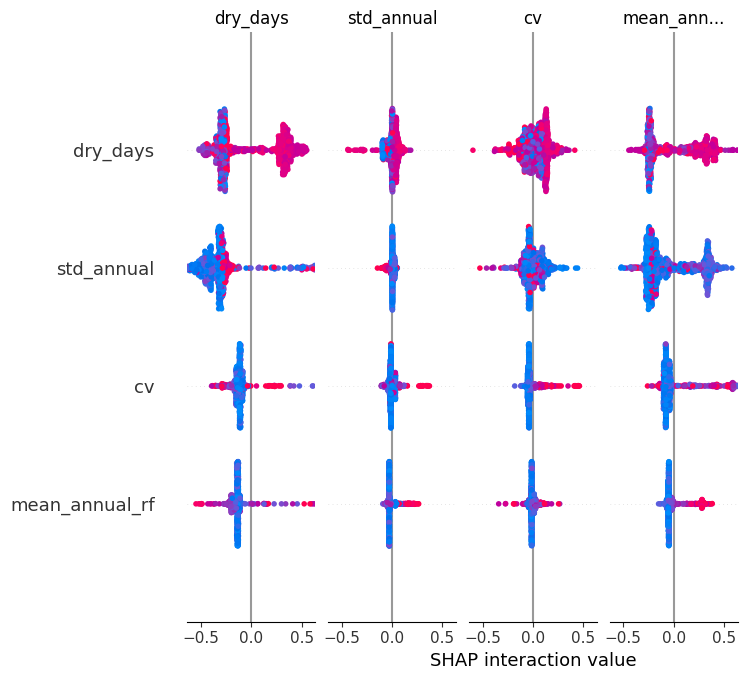

In [9]:
shap.summary_plot(
    shap_values,
    X_test
)

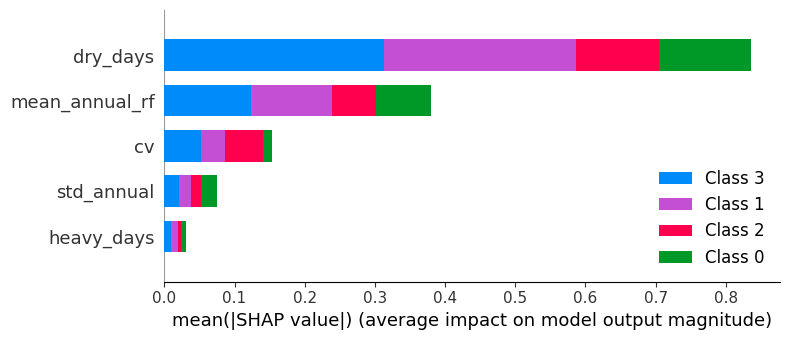

In [10]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

Waterfall Plot

In [13]:
print(shap_values.shape)

(993, 5, 4)


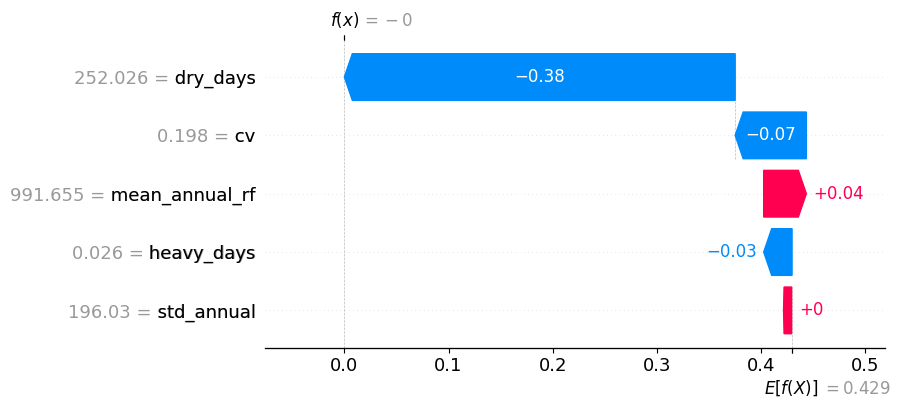

In [14]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0, :, 3],  # Critical class
        base_values=explainer.expected_value[3],
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)